# EDA: ALI=F (Clean Event-Based)
### Exploratory Data Analysis - Ringkas & To-the-Point

**Tujuan:** Memahami kualitas dan karakteristik data untuk Machine Learning

**Dataset:** Clean event-based (ali_f_event_clean.csv)


## 1️. Loading & Inspection

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def find_clean_data():
    roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    candidates = [r / 'data/processed data/ali_f_event_clean.csv' for r in roots]
    for p in candidates:
        if p.exists():
            return p, candidates
    return None, candidates

data_path, checked = find_clean_data()
if data_path is None:
    print('CWD:', Path.cwd())
    print('Checked paths:')
    for p in checked:
        print(' -', p)
    raise FileNotFoundError('Clean data not found in expected locations.')

df = pd.read_csv(data_path, parse_dates=['Date'])
df = df.set_index('Date').sort_index()

print(f'Data loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Periode: {df.index.min().date()} s/d {df.index.max().date()}')
df.head()


Data loaded: 2386 rows × 19 columns
Periode: 2014-05-06 s/d 2026-03-04


,Adj Close,Close,High,Low,Open,Repaired?,Volume,is_missing,is_stale,price_changed,streak_group,streak_len,volume_zero,flat_candle,Return,is_outlier_iqr,is_outlier_mad,next_day_after_long_streak,is_suspect_outlier
Date,,,,,,,,,,,,,,,,,,,
2014-05-06,2172.75,2172.75,2205.75,2165.00,2182.75,False,41,False,False,True,1,0,False,False,NaN,False,False,False,False
2014-05-07,2149.00,2149.00,2152.25,2146.00,2152.25,False,35,False,False,True,1,0,False,False,-0.010931,False,False,False,False
2014-05-08,2141.75,2141.75,2150.00,2130.00,2150.00,False,25,False,False,True,1,0,False,False,-0.003374,False,False,False,False
2014-05-09,2107.25,2107.25,2133.50,2107.25,2133.50,False,14,False,False,True,1,0,False,False,-0.016108,False,False,False,False
2014-05-12,2088.25,2088.25,2088.25,2086.00,2086.00,False,4,False,False,True,1,0,False,False,-0.009016,False,False,False,False


## 2️. Data Quality Check (FASE TERPENTING!)

### 2.1 Missing Values

MISSING VALUES SUMMARY


,Missing Count,Percentage (%)
Return,1,0.04


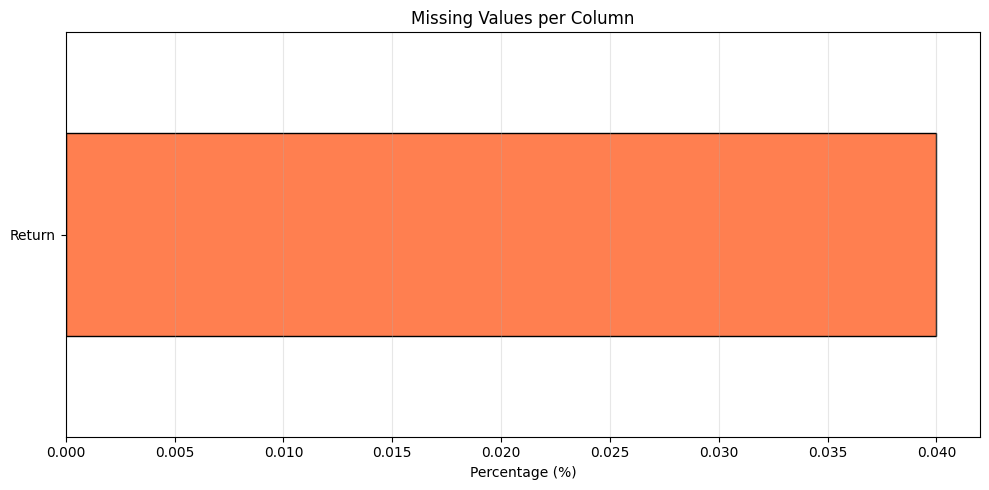

In [2]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = round(missing / len(df) * 100, 2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

print("MISSING VALUES SUMMARY")
print("="*50)
display(missing_df[missing_df['Missing Count'] > 0])

# Visualisasi
plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Percentage (%)')
plt.title('Missing Values per Column')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Detail NaN dates untuk Close
if missing.get('Close', 0) > 0:
    nan_dates = df[df['Close'].isna()].index.tolist()
    print(f"\nClose NaN: {len(nan_dates)} tanggal")
    print(f"   Rentang: {min(nan_dates).date()} s/d {max(nan_dates).date()}")

### 2.2 Repaired Data Flag

In [3]:
# Repaired flag analysis
if 'Repaired?' in df.columns:
    repaired_count = df['Repaired?'].sum()
    repaired_pct = round(repaired_count / len(df) * 100, 2)
    
    print("REPAIRED DATA SUMMARY")
    print("="*50)
    print(f"Total data yang di-repair: {repaired_count} ({repaired_pct}%)")
    
    if repaired_count > 0:
        print("\nTanggal yang di-repair:")
        repaired_dates = df[df['Repaired?'] == True].index.tolist()
        for d in repaired_dates:
            print(f"   • {d.date()}")
else:
    print("Kolom 'Repaired?' tidak tersedia")

REPAIRED DATA SUMMARY
Total data yang di-repair: 4 (0.17%)

Tanggal yang di-repair:
   • 2024-11-15
   • 2025-05-26
   • 2025-06-19
   • 2025-07-04


### 2.3 Settlement-Style Data

SETTLEMENT-STYLE DATA (FLAT CANDLE)
Flat candle: 1923 hari (80.6%)
   Normal candle: 463 hari (19.40%)

Flat Candle per Tahun:
   2014: 62.7% ████████████
   2015: 72.3% ██████████████
   2016: 39.3% ███████
   2017: 92.3% ██████████████████
   2018: 100.0% ████████████████████
   2019: 91.2% ██████████████████
   2020: 97.1% ███████████████████
   2021: 96.9% ███████████████████
   2022: 96.8% ███████████████████
   2023: 81.0% ████████████████
   2024: 79.0% ███████████████
   2025: 79.3% ███████████████
   2026: 61.9% ████████████


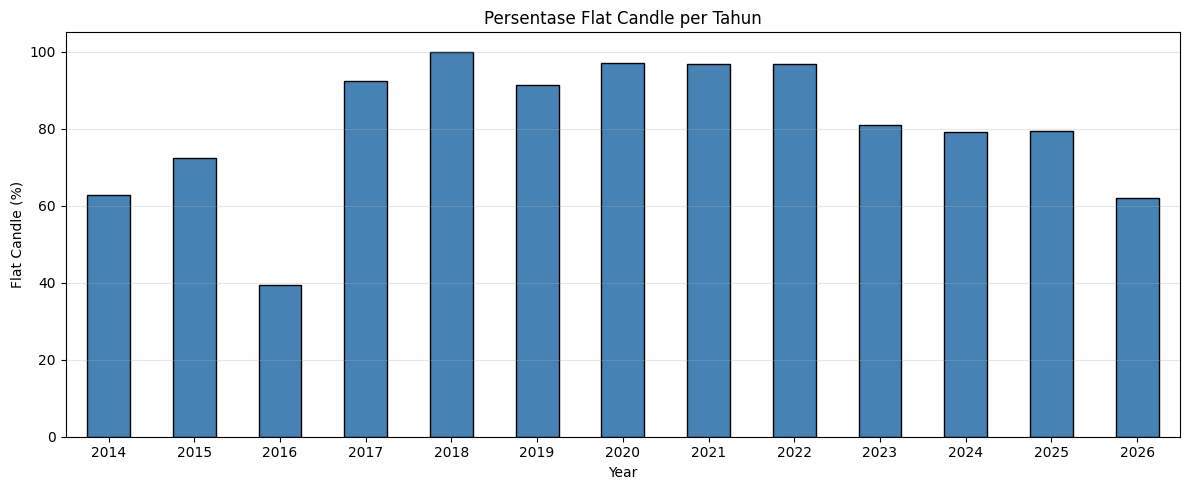


IMPLIKASI:
   • Data ini adalah settlement-style (1 harga/hari)
   • Open/High/Low = Close (disalin, bukan trading intraday)
   • Tidak cocok untuk analisis candlestick
   • Masih OK untuk forecasting return/price


In [4]:
# Deteksi flat candle (O=H=L=C)
flat_mask = (df['Open'] == df['High']) & (df['High'] == df['Low']) & (df['Low'] == df['Close'])
flat_count = flat_mask.sum()
flat_pct = round(flat_count / len(df) * 100, 2)

print("SETTLEMENT-STYLE DATA (FLAT CANDLE)")
print("="*50)
print(f"Flat candle: {flat_count} hari ({flat_pct}%)")
print(f"   Normal candle: {len(df) - flat_count} hari ({100-flat_pct:.2f}%)")

# Per tahun
df_temp = df.copy()
df_temp['Year'] = df_temp.index.year
df_temp['Is_Flat'] = flat_mask
flat_by_year = df_temp.groupby('Year')['Is_Flat'].mean() * 100

print("\nFlat Candle per Tahun:")
for year, pct in flat_by_year.items():
    bar = '█' * int(pct/5)
    print(f"   {year}: {pct:.1f}% {bar}")

# Visualisasi
plt.figure(figsize=(12, 5))
flat_by_year.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Flat Candle (%)')
plt.title('Persentase Flat Candle per Tahun')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIMPLIKASI:")
print("   • Data ini adalah settlement-style (1 harga/hari)")
print("   • Open/High/Low = Close (disalin, bukan trading intraday)")
print("   • Tidak cocok untuk analisis candlestick")
print("   • Masih OK untuk forecasting return/price")

### 2.4 Stale / Plateau Behavior

In [5]:
# Deteksi streak harga konstan
df_temp = df.copy()
df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
df_temp['Streak_Length'] = df_temp.groupby('Streak_Group').cumcount() + 1

# Cari streak ≥5 hari
long_streaks = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group').size()
runs_ge_5 = (long_streaks >= 5).sum()
max_streak = long_streaks.max() if len(long_streaks) > 0 else 0

# Return = 0
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)
zero_return = (df_temp['Return'] == 0).sum()
zero_return_pct = round(zero_return / len(df) * 100, 2)

print("STALE / PLATEAU BEHAVIOR")
print("="*50)
print(f"Run dengan ≥5 hari konstan: {runs_ge_5} run")
print(f"Streak terpanjang: ~{max_streak} hari")
print(f"Hari dengan return = 0: {zero_return} ({zero_return_pct}%)")

# Tampilkan streak terpanjang
if max_streak >= 5:
    longest_streak_group = long_streaks[long_streaks == max_streak].index[0]
    streak_data = df_temp[df_temp['Streak_Group'] == longest_streak_group]
    print(f"\nStreak terpanjang:")
    print(f"   Dari: {streak_data.index.min().date()}")
    print(f"   Sampai: {streak_data.index.max().date()}")
    print(f"   Harga: {streak_data['Close'].iloc[0]}")

STALE / PLATEAU BEHAVIOR
Run dengan ≥5 hari konstan: 0 run
Streak terpanjang: ~0 hari
Hari dengan return = 0: 0 (0.0%)


#### Tabel Lengkap 17 Run Streak (≥5 Hari Konstan)

In [6]:
# Fungsi untuk ekstrak semua streak ≥5 hari
def extract_streaks(df, min_streak=5):
    """Extract semua streak periode dengan harga konstan"""
    df_temp = df.copy()
    df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
    df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
    
    # Group streak
    streak_groups = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group')
    streak_lengths = streak_groups.size()
    
    # Filter streak ≥ min_streak
    long_streaks = streak_lengths[streak_lengths >= min_streak]
    
    # Ekstrak detail setiap streak
    streak_details = []
    for i, (group_id, length) in enumerate(long_streaks.items(), 1):
        group_data = df_temp[df_temp['Streak_Group'] == group_id]
        start_date = group_data.index.min()
        end_date = group_data.index.max()
        price = group_data['Close'].iloc[0]
        
        # Kategorikan
        if length >= 30:
            kategori = 'Streak sangat panjang'
        elif length >= 10:
            kategori = 'Streak panjang'
        else:
            kategori = 'Streak pendek'
        
        # Cek jika ini missing data
        if pd.isna(price):
            kategori = 'Missing data block'
        
        streak_details.append({
            '#': i,
            'Start Date': start_date,
            'End Date': end_date,
            'Durasi (Hari)': length,
            'Harga Close': price,
            'Keterangan': kategori
        })
    
    columns = ['#','Start Date','End Date','Durasi (Hari)','Harga Close','Keterangan']
    if not streak_details:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(streak_details, columns=columns)

# Ekstrak dan tampilkan tabel
streak_table = extract_streaks(df, min_streak=5)

# Tampilkan dengan styling
print('='*100)
print('TABEL LENGKAP RUN STREAK (≥5 Hari Konstan)')
print('='*100)
print(f'\nTotal run: {len(streak_table)} periode')

if streak_table.empty:
    print('Tidak ada streak karena dataset ini event-based (harga berubah saja).')
else:
    print(f'Total hari dalam streak: {streak_table["Durasi (Hari)"].sum()} hari ({streak_table["Durasi (Hari)"].sum()/len(df)*100:.2f}% dari data)')
    print(f'\nStreak terpanjang: {streak_table["Durasi (Hari)"].max()} hari')
    print(f'Rata-rata durasi: {streak_table["Durasi (Hari)"].mean():.1f} hari\n')
    print('-'*100)

    # Display tabel
    display(streak_table.style.set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    }).format({
        'Start Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
        'End Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
        'Harga Close': lambda x: f"{x:,.2f}" if pd.notna(x) else 'NaN'
    }).background_gradient(subset=['Durasi (Hari)'], cmap='YlOrRd'))

    # Highlight streak terpanjang
    max_streak_idx = streak_table['Durasi (Hari)'].idxmax()
    print(f'\nSTREAK TERPANJANG: {streak_table.loc[max_streak_idx, "Start Date"].strftime("%Y-%m-%d")} s/d {streak_table.loc[max_streak_idx, "End Date"].strftime("%Y-%m-%d")}')
    print(f'Durasi: {streak_table.loc[max_streak_idx, "Durasi (Hari)"]} hari dengan harga {streak_table.loc[max_streak_idx, "Harga Close"]}')


TABEL LENGKAP RUN STREAK (≥5 Hari Konstan)

Total run: 0 periode
Tidak ada streak karena dataset ini event-based (harga berubah saja).


### 2.5 Outlier Detection

OUTLIER DETECTION (Return)
Statistik Return:
   Mean:   0.0003 (0.03%)
   Std:    0.0136 (1.36%)
   Min:    -0.2311 (-23.11%)
   Max:    0.0792 (7.92%)

Outlier (IQR method):
   Total: 64 (2.68%)
   Bound: [-0.0308, 0.0315]

Top 5 Return Ekstrem:


,Close,Return
Date,,
2019-07-01,1793.50,-0.231083
2021-10-22,2907.75,-0.064656
2022-10-19,2187.00,-0.064485
2023-01-04,2270.00,-0.058189
2022-08-31,2341.75,-0.056222


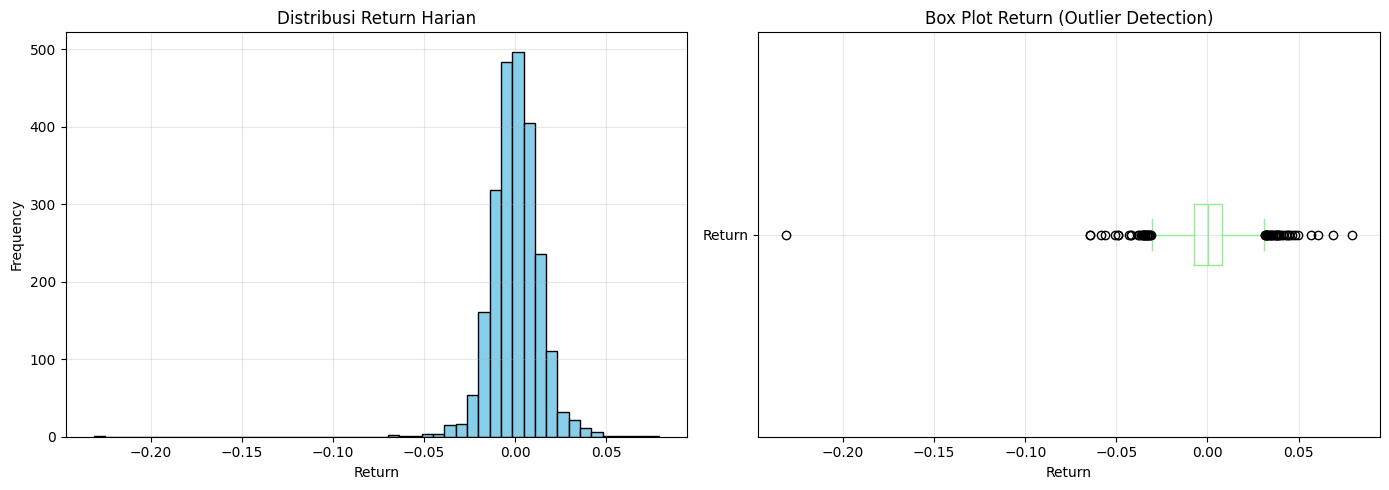


OUTLIER TERBESAR:
   Tanggal: 2019-07-01
   Return: -0.2311 (-23.11%)
   → Diduga artefak data (stale update)


In [7]:
# Hitung return
df_temp = df.copy()
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)

# Outlier dengan IQR
Q1 = df_temp['Return'].quantile(0.25)
Q3 = df_temp['Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_temp[(df_temp['Return'] < lower_bound) | (df_temp['Return'] > upper_bound)]
outlier_pct = round(len(outliers) / len(df) * 100, 2)

print("OUTLIER DETECTION (Return)")
print("="*50)
print(f"Statistik Return:")
print(f"   Mean:   {df_temp['Return'].mean():.4f} ({df_temp['Return'].mean()*100:.2f}%)")
print(f"   Std:    {df_temp['Return'].std():.4f} ({df_temp['Return'].std()*100:.2f}%)")
print(f"   Min:    {df_temp['Return'].min():.4f} ({df_temp['Return'].min()*100:.2f}%)")
print(f"   Max:    {df_temp['Return'].max():.4f} ({df_temp['Return'].max()*100:.2f}%)")
print(f"\nOutlier (IQR method):")
print(f"   Total: {len(outliers)} ({outlier_pct}%)")
print(f"   Bound: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Top 5 outliers
print("\nTop 5 Return Ekstrem:")
top_outliers = df_temp.nsmallest(5, 'Return')[['Close', 'Return']]
display(top_outliers)

# Visualisasi
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df_temp['Return'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Return')
plt.title('Distribusi Return Harian')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df_temp['Return'].plot(kind='box', vert=False, color='lightgreen')
plt.xlabel('Return')
plt.title('Box Plot Return (Outlier Detection)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Highlight outlier terbesar
max_outlier_date = df_temp['Return'].idxmin()
max_outlier_val = df_temp.loc[max_outlier_date, 'Return']
print(f"\nOUTLIER TERBESAR:")
print(f"   Tanggal: {max_outlier_date.date()}")
print(f"   Return: {max_outlier_val:.4f} ({max_outlier_val*100:.2f}%)")
print(f"   → Diduga artefak data (stale update)" if max_outlier_val < -0.1 else "   → Pergerakan normal")

In [8]:
# ============================================
# ANALISIS LANJUTAN: OUTLIER & STALE DATA
# ============================================

print("ANALISIS LANJUTAN: HUBUNGAN OUTLIER, VOLUME, DAN STREAK")

# Siapkan data dengan return
df_analysis = df.copy()
df_analysis['Return'] = df_analysis['Close'].pct_change(fill_method=None)

# Hitung IQR untuk outlier
Q1 = df_analysis['Return'].quantile(0.25)
Q3 = df_analysis['Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifikasi outlier
df_analysis['Is_Outlier'] = (df_analysis['Return'] < lower_bound) | (df_analysis['Return'] > upper_bound)

# Identifikasi volume = 0
df_analysis['Is_Zero_Volume'] = df_analysis['Volume'] == 0

# Identifikasi return = 0 (stale)
df_analysis['Is_Zero_Return'] = df_analysis['Return'] == 0

# 1. CEK: Berapa % outlier terjadi saat Volume=0?

outliers_df = df_analysis[df_analysis['Is_Outlier']].copy()
total_outliers = len(outliers_df)
outliers_zero_volume = (outliers_df['Is_Zero_Volume'] == True).sum()
pct_zero_volume = round(outliers_zero_volume / total_outliers * 100, 2)

print("\n" + "="*80)
print("1. OUTLIER vs VOLUME = 0")
print("="*80)
print(f"Total outlier: {total_outliers}")
print(f"Outlier dengan Volume = 0: {outliers_zero_volume} ({pct_zero_volume}%)")
print(f"Outlier dengan Volume > 0: {total_outliers - outliers_zero_volume} ({100-pct_zero_volume:.2f}%)")

if pct_zero_volume >= 40:
    print(f"\nTEMUAN: ~{pct_zero_volume:.0f}% outlier terjadi saat Volume=0")

ANALISIS LANJUTAN: HUBUNGAN OUTLIER, VOLUME, DAN STREAK

1. OUTLIER vs VOLUME = 0
Total outlier: 64
Outlier dengan Volume = 0: 26 (40.62%)
Outlier dengan Volume > 0: 38 (59.38%)

TEMUAN: ~41% outlier terjadi saat Volume=0


In [9]:
# 2. CEK: Outlier setelah jeda kalender panjang (event-based)

# Pastikan df_analysis sudah ada dari cell sebelumnya
if 'df_analysis' not in globals():
    df_analysis = df.copy()
    df_analysis['Return'] = df_analysis['Close'].pct_change(fill_method=None)

    # Hitung IQR untuk outlier
    Q1 = df_analysis['Return'].quantile(0.25)
    Q3 = df_analysis['Return'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_analysis['Is_Outlier'] = (df_analysis['Return'] < lower_bound) | (df_analysis['Return'] > upper_bound)
    df_analysis['Is_Zero_Volume'] = df_analysis['Volume'] == 0

# Hitung jeda kalender antar event
df_analysis['Gap_Days'] = df_analysis.index.to_series().diff().dt.days
gap_threshold = 7  # event setelah jeda >= 7 hari
df_analysis['Is_Long_Gap'] = df_analysis['Gap_Days'] >= gap_threshold

print('\n' + '='*80)
print('2. OUTLIER SETELAH JEDA KALENDER PANJANG')
print('='*80)
print(f'Threshold jeda: >= {gap_threshold} hari')
print(f'Total event dengan jeda panjang: {int(df_analysis["Is_Long_Gap"].sum())}')

outliers_after_gap = df_analysis[
    (df_analysis['Is_Outlier']) &
    (df_analysis['Is_Long_Gap'])
][['Close', 'Return', 'Volume', 'Gap_Days']]

print(f'Total outlier setelah jeda panjang: {len(outliers_after_gap)}')

if len(outliers_after_gap) > 0:
    print('\nDetail outlier setelah jeda panjang:')
    display(outliers_after_gap.sort_values('Return').head(10))

    max_after_gap = outliers_after_gap['Return'].idxmin()
    print('\nOUTLIER TERBESAR SETELAH JEDA PANJANG:')
    print(f'Tanggal: {max_after_gap.date()}')
    print(f'Return: {df_analysis.loc[max_after_gap, "Return"]:.4f} ({df_analysis.loc[max_after_gap, "Return"]*100:.2f}%)')
    print(f'Jeda sebelumnya: {df_analysis.loc[max_after_gap, "Gap_Days"]} hari')
else:
    print('Tidak ada outlier setelah jeda panjang.')



2. OUTLIER SETELAH JEDA KALENDER PANJANG
Threshold jeda: >= 7 hari
Total event dengan jeda panjang: 20
Total outlier setelah jeda panjang: 3

Detail outlier setelah jeda panjang:


,Close,Return,Volume,Gap_Days
Date,,,,
2019-07-01,1793.50,-0.231083,0,214.0
2022-03-09,3286.50,-0.038191,1,9.0
2016-09-29,1726.25,0.049552,8,27.0



OUTLIER TERBESAR SETELAH JEDA PANJANG:
Tanggal: 2019-07-01
Return: -0.2311 (-23.11%)
Jeda sebelumnya: 214.0 hari


In [10]:
# 3. CEK: Detail outlier terbesar (event-based)

print('\n' + '='*80)
print('3. ANALISIS MENDALAM: OUTLIER TERBESAR (EVENT-BASED)')
print('='*80)

# Pastikan df_analysis ada
if 'df_analysis' not in globals():
    df_analysis = df.copy()
    df_analysis['Return'] = df_analysis['Close'].pct_change(fill_method=None)

# Outlier terbesar (return paling negatif)
max_outlier_date = df_analysis['Return'].idxmin()

# Window berbasis event (±10 event)
pos = df_analysis.index.get_loc(max_outlier_date)
start_pos = max(0, pos - 10)
end_pos = min(len(df_analysis) - 1, pos + 10)
window_data = df_analysis.iloc[start_pos:end_pos+1][['Close', 'Volume', 'Return']]

# Hitung gap hari antar event
window_data = window_data.copy()
window_data['Gap_Days'] = window_data.index.to_series().diff().dt.days

print(f'Event window: index {start_pos} s/d {end_pos} (±10 event)')
print(f'Total event di window: {len(window_data)}')
print(f'Event dengan Volume=0: {(window_data["Volume"]==0).sum()}')

print('\nDATA SEBELUM & SESUDAH OUTLIER:')
display(window_data)

print('\nOUTLIER TERBESAR:')
print(f'Tanggal: {max_outlier_date.date()}')
print(f'Close: {df_analysis.loc[max_outlier_date, "Close"]}')
print(f'Return: {df_analysis.loc[max_outlier_date, "Return"]:.4f} ({df_analysis.loc[max_outlier_date, "Return"]*100:.2f}%)')

# Gap sebelum outlier (berapa hari sejak event sebelumnya)
gap_before = df_analysis.index.to_series().diff().dt.days.loc[max_outlier_date]
print(f'Jeda sebelum outlier: {gap_before} hari')



3. ANALISIS MENDALAM: OUTLIER TERBESAR (EVENT-BASED)
Event window: index 793 s/d 813 (±10 event)
Total event di window: 21
Event dengan Volume=0: 21

DATA SEBELUM & SESUDAH OUTLIER:


,Close,Volume,Return,Gap_Days
Date,,,,
2018-02-27,2255.00,0,0.002222,NaN
2018-03-28,2260.00,0,0.002217,29.0
2018-04-02,2300.00,0,0.017699,5.0
2018-05-30,2305.00,0,0.002174,58.0
2018-06-28,2309.25,0,0.001844,29.0
2018-07-30,2313.50,0,0.001840,32.0
2018-08-30,2318.75,0,0.002269,31.0
2018-09-27,2323.00,0,0.001833,28.0
2018-10-30,2328.25,0,0.002260,33.0



OUTLIER TERBESAR:
Tanggal: 2019-07-01
Close: 1793.5
Return: -0.2311 (-23.11%)
Jeda sebelum outlier: 214.0 hari


In [11]:
# 5. CEK: IQR hanya pada return non-zero

print("\n" + "="*80)
print("4. IQR HANYA PADA RETURN NON-ZERO")
print("="*80)

# Filter hanya return non-zero
df_non_zero = df_analysis[df_analysis['Return'] != 0].copy()

# Hitung IQR baru
Q1_nz = df_non_zero['Return'].quantile(0.25)
Q3_nz = df_non_zero['Return'].quantile(0.75)
IQR_nz = Q3_nz - Q1_nz
lower_bound_nz = Q1_nz - 1.5 * IQR_nz
upper_bound_nz = Q3_nz + 1.5 * IQR_nz

# Hitung outlier dengan IQR baru
df_analysis['Is_Outlier_NZ'] = (df_analysis['Return'] < lower_bound_nz) | (df_analysis['Return'] > upper_bound_nz)
outliers_nz = df_analysis[df_analysis['Is_Outlier_NZ'] & (df_analysis['Return'] != 0)]

print(f"\nPERBANDINGAN IQR:")
print(f"\nIQR Standard (semua return):")
print(f"Q1: {Q1:.6f}")
print(f"Q3: {Q3:.6f}")
print(f"IQR: {IQR:.6f}")
print(f"Bound: [{lower_bound:.6f}, {upper_bound:.6f}]")
print(f"Total outlier: {total_outliers} ({round(total_outliers/len(df)*100, 2)}%)")

print(f"\nIQR Non-Zero Return (exclude return=0):")
print(f"Q1: {Q1_nz:.6f}")
print(f"Q3: {Q3_nz:.6f}")
print(f"IQR: {IQR_nz:.6f}")
print(f"Bound: [{lower_bound_nz:.6f}, {upper_bound_nz:.6f}]")
print(f"Total outlier: {len(outliers_nz)} ({round(len(outliers_nz)/len(df)*100, 2)}%)")

reduction = total_outliers - len(outliers_nz)
reduction_pct = round(reduction / total_outliers * 100, 2)

print(f"\nREDUKSI OUTLIER:")
print(f"Pengurangan: {reduction} outlier ({reduction_pct}% lebih sedikit)")


4. IQR HANYA PADA RETURN NON-ZERO

PERBANDINGAN IQR:

IQR Standard (semua return):
Q1: -0.007468
Q3: 0.008110
IQR: 0.015578
Bound: [-0.030836, 0.031478]
Total outlier: 64 (2.68%)

IQR Non-Zero Return (exclude return=0):
Q1: -0.007468
Q3: 0.008110
IQR: 0.015578
Bound: [-0.030836, 0.031478]
Total outlier: 64 (2.68%)

REDUKSI OUTLIER:
Pengurangan: 0 outlier (0.0% lebih sedikit)


## 3️. Univariate Analysis

DESCRIPTIVE STATISTICS


,Open,High,Low,Close,Volume
count,2386.000000,2386.000000,2386.000000,2386.000000,2386.000000
mean,2194.277661,2195.575650,2193.074078,2194.387154,9.994552
std,408.307084,408.553228,408.460769,408.604948,53.061647
min,1456.000000,1456.000000,1452.000000,1452.000000,0.000000
25%,1825.062500,1825.750000,1823.062500,1823.812500,0.000000
50%,2209.375000,2210.500000,2208.250000,2209.750000,0.000000
75%,2463.187500,2463.937500,2462.062500,2462.812500,10.000000
max,3593.500000,3593.500000,3593.500000,3593.500000,2210.000000


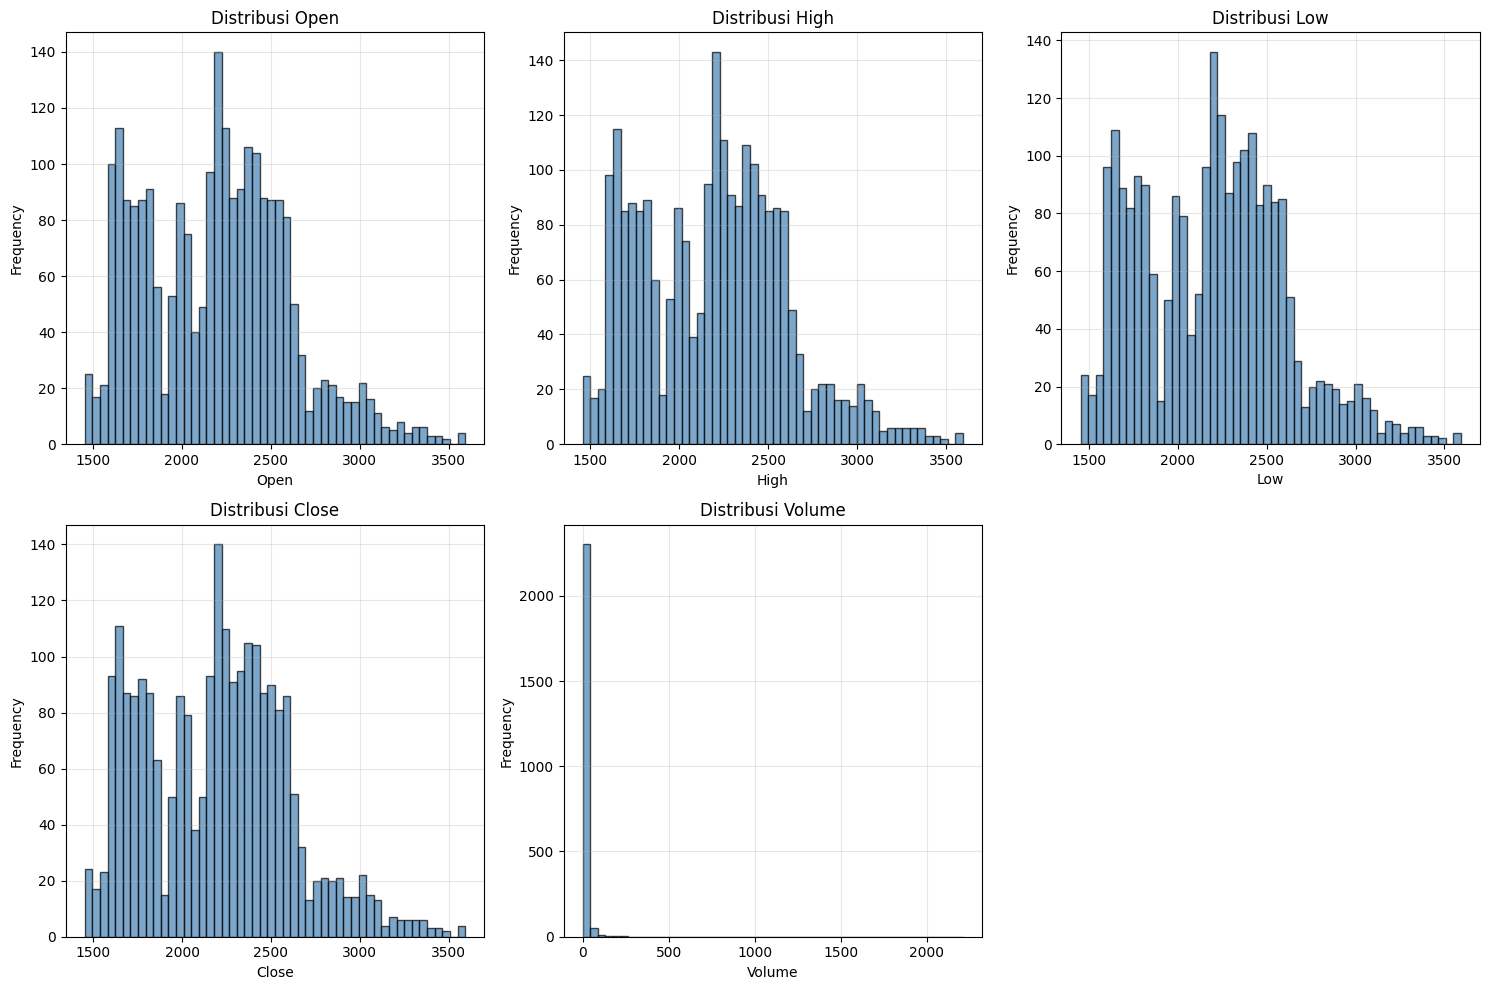

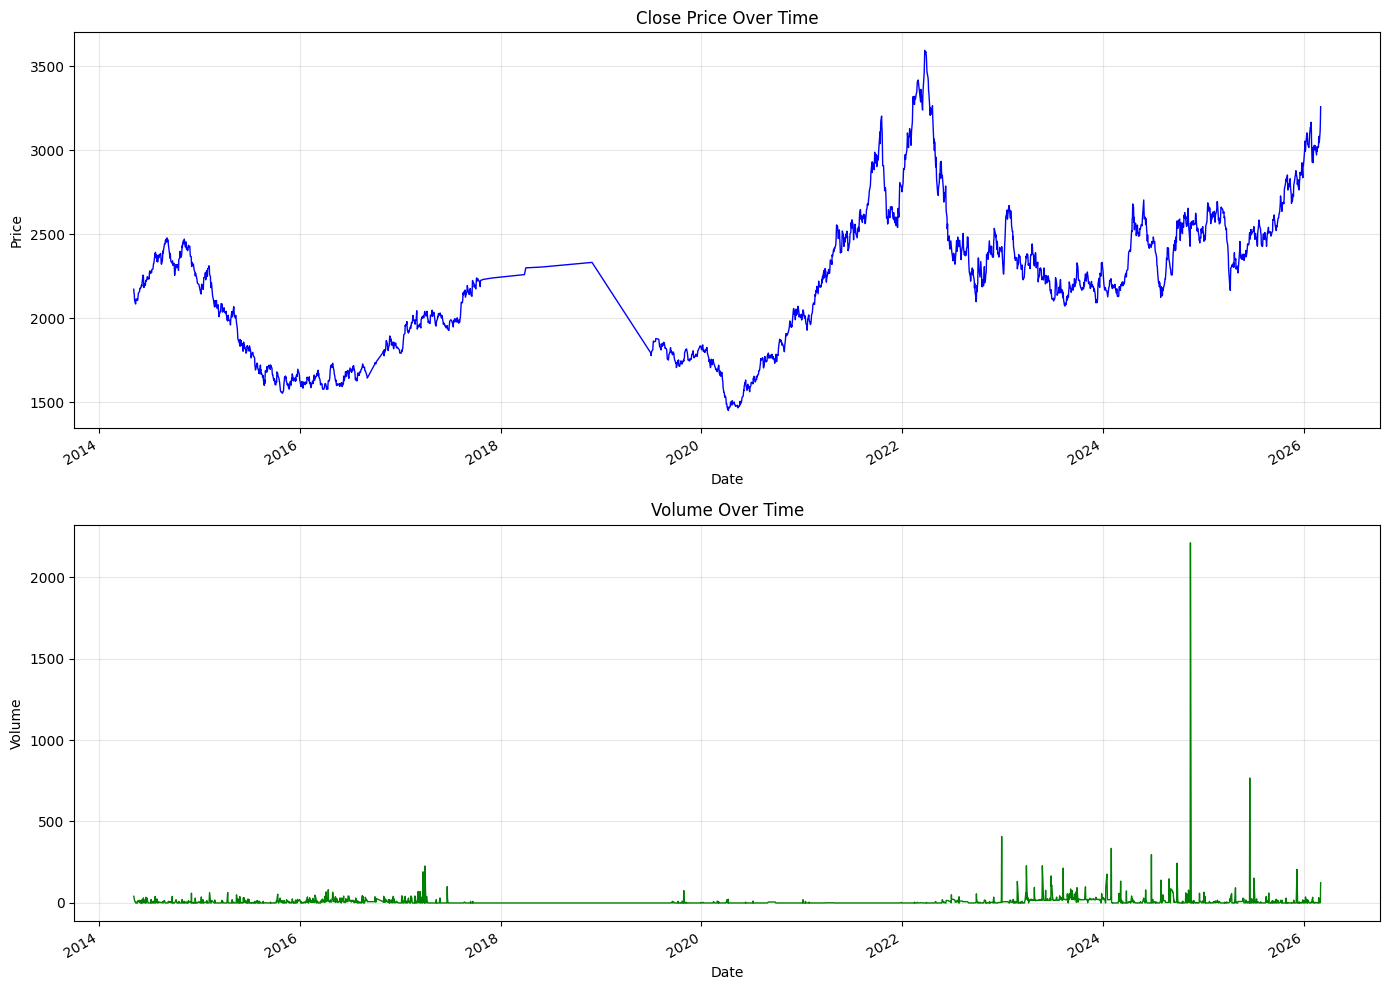

In [12]:
# Statistik deskriptif
print("DESCRIPTIVE STATISTICS")
print("="*60)
display(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

# Visualisasi distribusi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for idx, col in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    df[col].plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_title(f'Distribusi {col}')
    ax.grid(alpha=0.3)

# Kosongkan subplot terakhir
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Close price
df['Close'].plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_ylabel('Price')
axes[0].set_title('Close Price Over Time')
axes[0].grid(alpha=0.3)

# Volume
df['Volume'].plot(ax=axes[1], color='green', linewidth=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Volume Over Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4️. Bivariate & Multivariate Analysis

CORRELATION MATRIX


,Open,High,Low,Close,Volume
Open,1.00,1.000,1.000,1.00,0.020
High,1.00,1.000,1.000,1.00,0.021
Low,1.00,1.000,1.000,1.00,0.019
Close,1.00,1.000,1.000,1.00,0.020
Volume,0.02,0.021,0.019,0.02,1.000


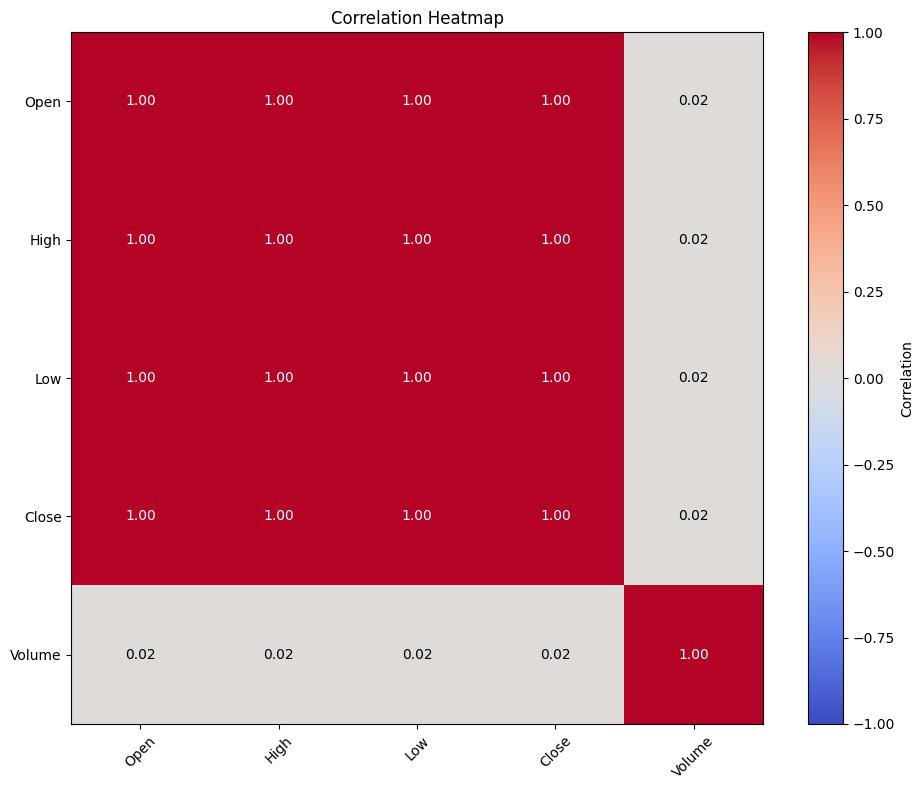


SCATTER PLOT MATRIX (sample 500 data)


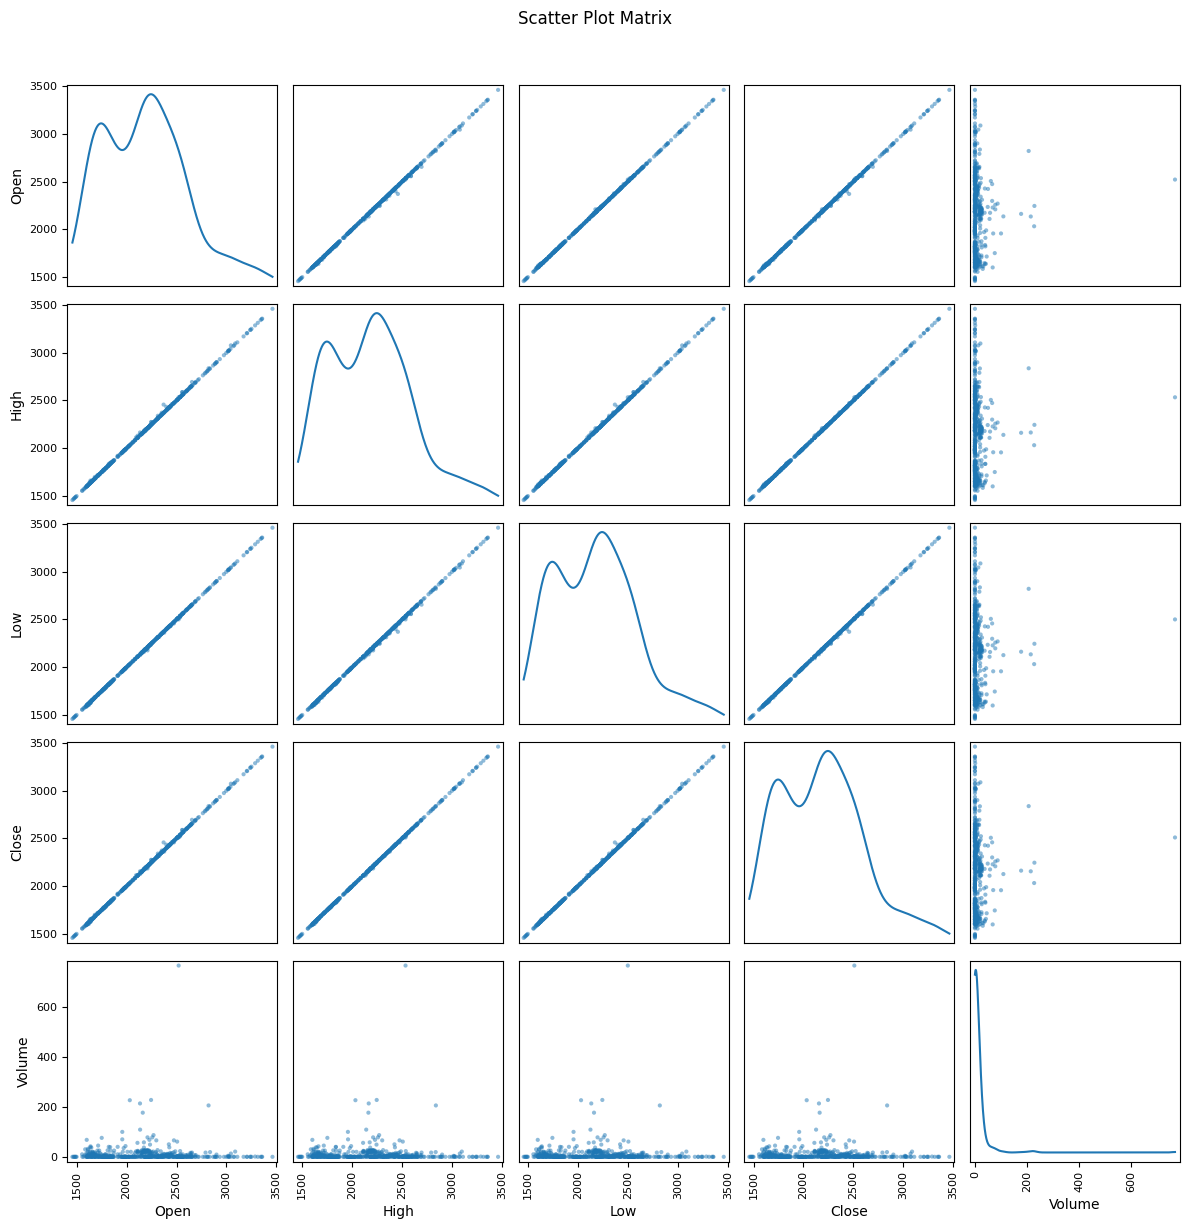

In [13]:
# Correlation matrix
print("CORRELATION MATRIX")
print("="*60)
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = df[corr_cols].corr()
display(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Heatmap')

# Anotasi nilai
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', 
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

# Scatter plot matrix (sample untuk performa)
print("\nSCATTER PLOT MATRIX (sample 500 data)")
df_sample = df.sample(500, random_state=42)
pd.plotting.scatter_matrix(df_sample[corr_cols], figsize=(12, 12), alpha=0.5, diagonal='kde')
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.tight_layout()
plt.show()

PRICE vs VOLUME


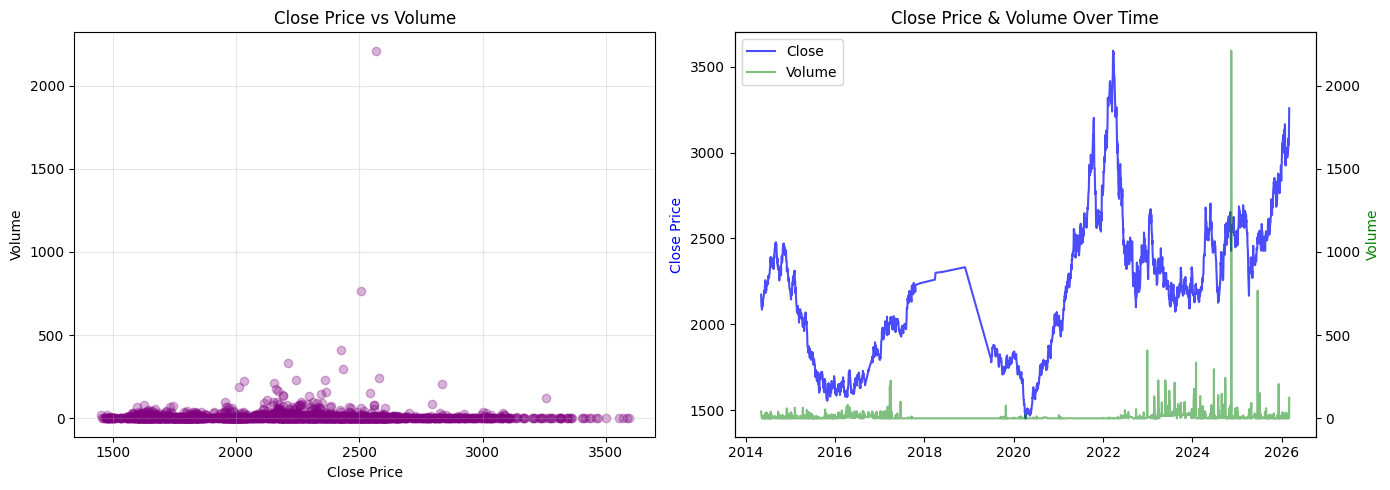

In [14]:
# Price vs Volume relationship
print("PRICE vs VOLUME")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Close'], df['Volume'], alpha=0.3, color='purple')
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Volume')
axes[0].set_title('Close Price vs Volume')
axes[0].grid(alpha=0.3)

# Time series dengan dual axis
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df.index, df['Close'], color='blue', label='Close', alpha=0.7)
ax2.plot(df.index, df['Volume'], color='green', label='Volume', alpha=0.5)

ax1.set_ylabel('Close Price', color='blue')
ax2.set_ylabel('Volume', color='green')
ax1.set_title('Close Price & Volume Over Time')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()